# Preprocessing for Game of Life Mosaics

The quickstart turns an image into a mosaic in a single call. This notebook opens
up the **preprocessing** that runs first — how a raw colour photo becomes the
greyscale, background-removed, high-contrast image the mosaic is built from — and
shows how to tune each step.

1. The preprocessing pipeline, step by step
2. Contrast settings (the S-curve)
3. Background-removal settings (models and alpha matting)

All of these live on `ImageProcessor`; `generate_from_image` calls them for you
with sensible defaults.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from gol_mosaics import ImageProcessor

%load_ext autoreload
%autoreload 2

Load the raw colour photo we will work with:

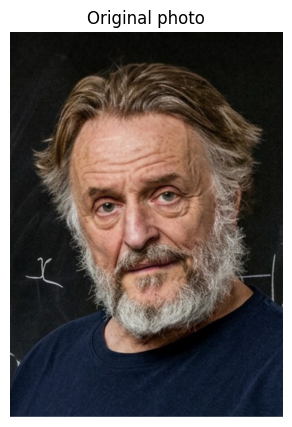

In [2]:
input_path = '../input/images/john-original.png'
original = Image.open(input_path)

plt.figure(figsize=(5, 5))
plt.imshow(original)
plt.title('Original photo')
plt.axis('off')
plt.show()

## 1. The preprocessing pipeline, step by step

`ImageProcessor.load_image` bundles the stages below: detect and remove the
background, flatten to greyscale, and boost the contrast. Here we run them one at
a time to see what each does.

### Detect the background

In [3]:
print('Background still present?', ImageProcessor.has_background(original))

Background still present? True


### Remove the background

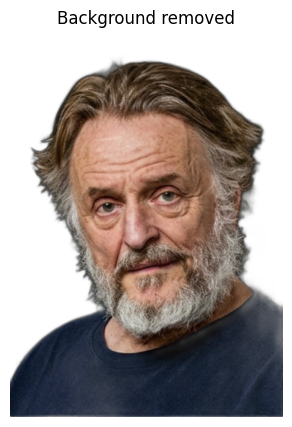

In [4]:
no_background = ImageProcessor.remove_background(original)

plt.figure(figsize=(5, 5))
plt.imshow(no_background)
plt.title('Background removed')
plt.axis('off')
plt.show()

### The alpha mask

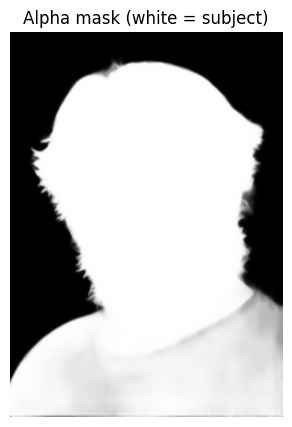

In [5]:
alpha_mask = no_background.split()[-1]

plt.figure(figsize=(5, 5))
plt.imshow(alpha_mask, cmap='gray')
plt.title('Alpha mask (white = subject)')
plt.axis('off')
plt.show()

### Greyscale

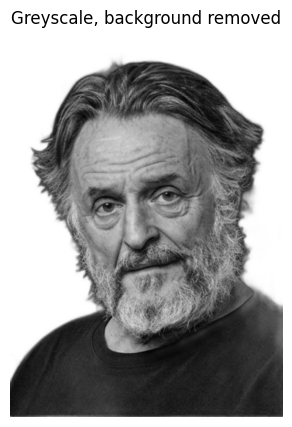

In [6]:
white_bg = Image.new('RGBA', no_background.size, 'white')
white_bg.paste(no_background, mask=alpha_mask)
greyscale = white_bg.convert('L')

plt.figure(figsize=(5, 5))
plt.imshow(greyscale, cmap='gray')
plt.title('Greyscale, background removed')
plt.axis('off')
plt.show()

### Contrast boost (S-curve)

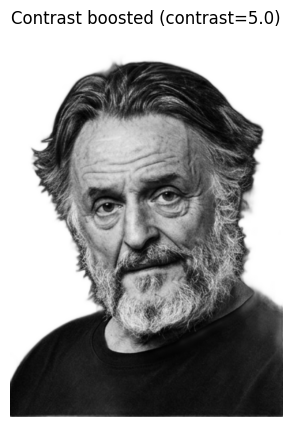

In [7]:
high_contrast = ImageProcessor.enhance_contrast(greyscale, contrast=5.0)

plt.figure(figsize=(5, 5))
plt.imshow(high_contrast, cmap='gray')
plt.title('Contrast boosted (contrast=5.0)')
plt.axis('off')
plt.show()

Running `ImageProcessor.load_image(input_path)` performs exactly these stages in
one call (auto background removal + greyscale + contrast), and
`generate_from_image` runs it for you before building the mosaic.

## 2. Contrast settings

The contrast step uses a smooth **S-curve** (sigmoid): it pushes light tones
lighter and dark tones darker while leaving pure black and white fixed. The
strength is the `contrast` value — 0 leaves the image unchanged, higher is
punchier. The pipeline default is `contrast=5.0`.

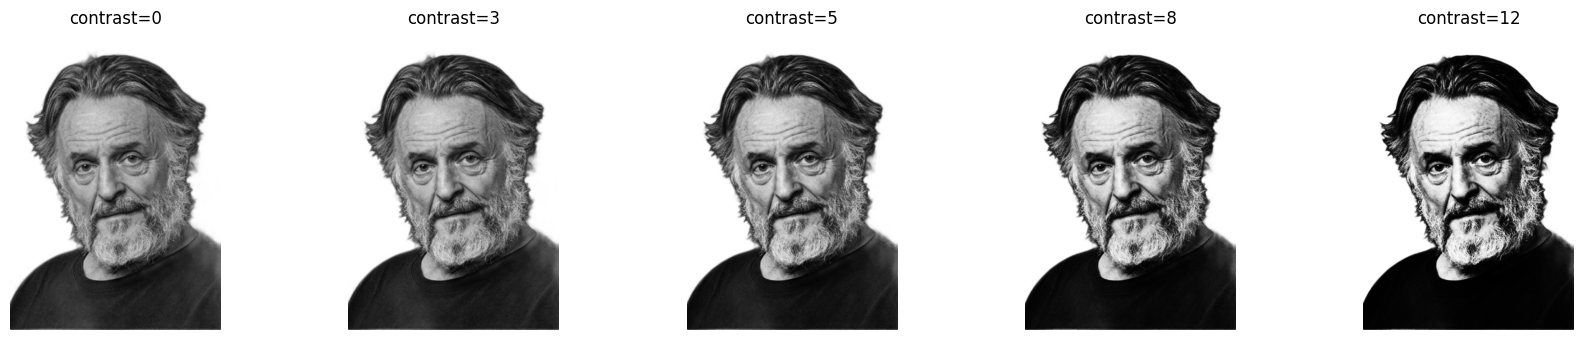

In [8]:
contrasts = [0, 3, 5, 8, 12]
fig, axes = plt.subplots(1, len(contrasts), figsize=(3.5 * len(contrasts), 3.5))
for ax, c in zip(axes, contrasts):
    ax.imshow(ImageProcessor.enhance_contrast(greyscale, contrast=c),
              cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'contrast={c}')
    ax.axis('off')
plt.tight_layout()
plt.show()

`midpoint` (0-1) shifts where the curve pivots: a lower midpoint lightens more of
the image, a higher one darkens more. Default is 0.5 (mid-grey).

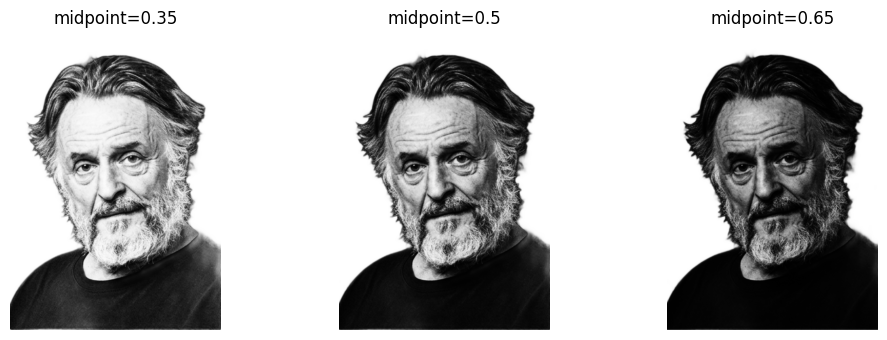

In [9]:
midpoints = [0.35, 0.5, 0.65]
fig, axes = plt.subplots(1, len(midpoints), figsize=(3.5 * len(midpoints), 3.5))
for ax, m in zip(axes, midpoints):
    ax.imshow(ImageProcessor.enhance_contrast(greyscale, contrast=8, midpoint=m),
              cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'midpoint={m}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Background-removal settings

`remove_background` accepts a `model` (which segmentation network to use) and an
`alpha_matting` flag (edge refinement). The galleries below run on a downscaled
copy of the photo, since segmentation — and especially alpha matting — is slow at
full resolution.

In [10]:
w, h = original.size
small = original.resize((320, round(320 * h / w)))

### Different models

Each rembg model segments a little differently. `u2net` is the general-purpose
default; `u2net_human_seg` is tuned for people; `isnet-general-use` and `silueta`
are alternatives. Each model downloads once on first use.

> **You may see `Context leak detected, CoreAnalytics returned false` printed
> here, possibly several times.** This is harmless macOS log noise from Apple's
> CoreML/Metal layer, emitted when each model creates a GPU inference session on
> Apple Silicon — it is not a Python error and does not affect the results. It
> comes from the system frameworks below `onnxruntime`'s CoreML provider, so it
> cannot be fixed from this library. To avoid it, force CPU execution before the
> first removal (slightly slower, no CoreML, so no message):
>
> ```python
> ImageProcessor.background_removal_providers = ['CPUExecutionProvider']
> ```

Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak detected, CoreAnalytics returned false
Context leak

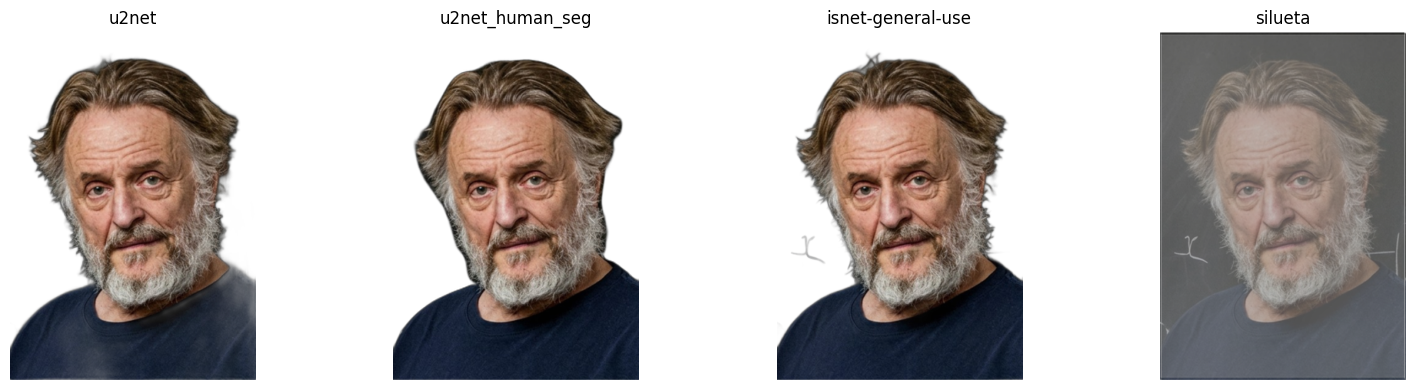

In [11]:
models = ['u2net', 'u2net_human_seg', 'isnet-general-use', 'silueta']
fig, axes = plt.subplots(1, len(models), figsize=(4 * len(models), 4))
for ax, name in zip(axes, models):
    ax.imshow(ImageProcessor.remove_background(small, model=name))
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Alpha matting (edge refinement)

Alpha matting softens and refines the cutout edges (hair, wisps) at the cost of
speed. Fine-tune it with `alpha_matting_foreground_threshold`,
`alpha_matting_background_threshold`, and `alpha_matting_erode_size`.

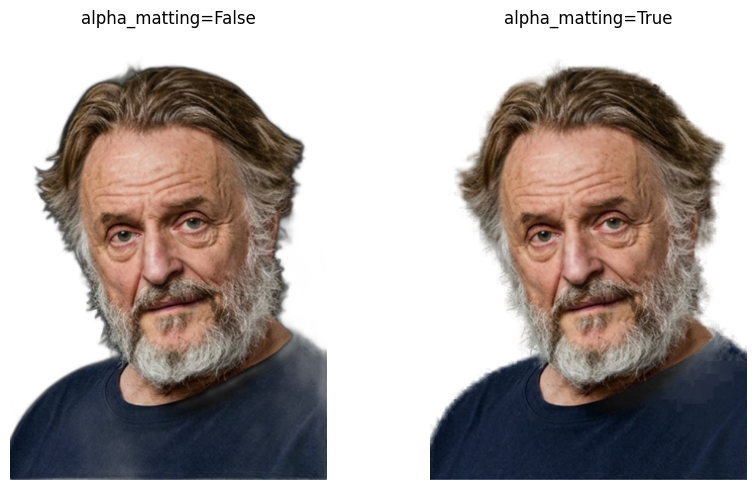

In [12]:
plain = ImageProcessor.remove_background(small, model='u2net')
matted = ImageProcessor.remove_background(small, model='u2net', alpha_matting=True)

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
for ax, (title, im) in zip(axes, [('alpha_matting=False', plain),
                                  ('alpha_matting=True', matted)]):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Notes

- In the mosaic pipeline the defaults are `model='u2net'`, no alpha matting, and
  `contrast=5.0`. To use a different model or alpha matting, call
  `ImageProcessor.remove_background(...)` directly.
- Removal automatically runs on the GPU/accelerator when available (CoreML on
  Apple Silicon, CUDA with `onnxruntime-gpu`) and otherwise on the CPU. Force a
  specific backend with `ImageProcessor.background_removal_providers`.